# Project Cycle 3 - Extension 1 - Female Smoker Behavioral Profile

## 1. Import Libraries

In [185]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu 
from scipy.stats import chi2_contingency

pd.set_option("display.max_columns", None)

### Introduction

This extension analysis focuses on behavioral characteristics among female students in the YRBS 2007 dataset.

The original Cycle 3 analysis examined whether current cigarette use differed between male and female students. This notebook extends the analysis by focusing specifically on female students and comparing behavioral and psychological characteristics between female smokers and female non-smokers.

The purpose of this extension analysis is to investigate whether smoking behavior among female students co-occurs with other behavioral and psychological risk factors, including alcohol use, binge drinking, marijuana use, physical fighting, sleep patterns, and sadness or hopelessness.

## 2. Load Dataset

The YRBS 2007 dataset is loaded from the raw data folder.

Before beginning the analysis, the dataset shape and first few rows are checked to confirm that the file was imported correctly.

In [186]:
# 2. Load Dataset

df = pd.read_csv("../data/raw/YRBS_2007.csv")

print(df.shape)

df.head()

(14041, 103)


,RaceEth,HowOldAreYou,WhatIsYourSex,InWhatGradeAreYou,AreYouHispanicOrLatino,WhatIsYourRace,HowTallAreYouWithoutShoesInMeters,HowMuchDoYouWeighWithoutShoesInKG,BicyleHelmetUse,SeatBeltUse,RidingWithADrinkingDriver,DrinkingAndDriving,WeaponCarrying,GunCarryingPast12Mos,WeaponCarryingAtSchool,SafetyConcernsAtSchool,WereThreatenedOrInjuredWithAWeaponOnSchoolProperty,StolenOrDamagedYourProperty,PhysicalFighting,InjuredIFight,PhysicalFightingAtSchool,BoyfriendGirlfriendPhysicallyHurt,ForcedSexualIntercourse,SadOrHopeless,ConsideredSuicide,MadeASuicidePlan,AttemptedSuicide,InjuriousSuicide,EverCigaretteUse,InitiationSmokingWholeCigarette,CurrentCigaretteUse,SmokedMoreThan10Cigarettes,HowObtainedCigarettes,SmokeOnSchoolProperty,EverSmokedDailyFor30Days,EverSmokingCessation,CurrentSmokelessTobaccoUse,CurrentSmokelessTobaccoOnSchoolProperty,CurrentCigarUse,EverAlcoholUse,InitiationOfAlcoholUse,CurrentAlcoholUse,CurrentBingeDrinking5OrMore,SourceOfAlcohol,DrinkAlcoholOnSchoolProperty,EverMarijuaUse,InitiationOfMarijuaUse,CurrentMarijuaUse,MarijuaOnSchoolProperty,EverCocaineUse,CocaineUsePast30Days,EverInhalantUse,EverHeroinUse,EverMethamphetamineUse,EverEcstasyUse,EverSteriodUse,IllegalInjectedDrugUse,IllegalDrugsAtSchool,EverSexualIntercourse,FirstSexualIntercourse,MultipleSexPartners,CurrentSexualActivity,AlcoholDrugsAndSex,CondomUse,BirthControlPillUse,PerceptionOfWeight,WeightLoss,ExerciseToLoseWeight,ConsumeFewerCaloriesToLoseWeight,FastingToLoseWeight,DietPillsToLoseWeight,LaxativesToLoseWeight,FruitJuiceDrinking,FruitEating,GreenSaladEating,PotatoEating,CarrotEating,OtherVegetableEating,NoSodaDrinking,NoMilkDrinking,PhysicalActivity5OrMoreDays,TelevisionWatching,ComputerUse,PEAttendance,SportsTeamParticipation,TaughtAboutHIV,Asthma,StillHaveAsthma,UsedMotorcycleHelmet,EverUsedLSD,AerobicExercise,NoerobicExercise,MinutesInPEPlayingSports,InjuredWhileExercising,HIVTesting,SunscreenUse,SunProtection,Sleep,HealthInGeneral,BMIPCT,weight,stratum,psu
0,7.0,4.0,2.0,2.0,1.0,C,NaN,NaN,2.0,1.0,5.0,5.0,4.0,3.0,1.0,5.0,6.0,3.0,8.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,2.0,7.0,7.0,2.0,3.0,1.0,3.0,5.0,4.0,4.0,NaN,2.0,NaN,4.0,5.0,3.0,NaN,2.0,NaN,NaN,5.0,2.0,4.0,6.0,4.0,4.0,3.0,1.0,2.0,1.0,6.0,5.0,4.0,2.0,3.0,2.0,3.0,3.0,1.0,1.0,2.0,2.0,2.0,5.0,5.0,3.0,2.0,1.0,1.0,7.0,5.0,5.0,4.0,2.0,1.0,1.0,1.0,2.0,3.0,2.0,2.0,6.0,8.0,1.0,3.0,2.0,1.0,1.0,5.0,3.0,NaN,1.5104,101,11030
1,5.0,7.0,2.0,2.0,2.0,E,1.70,68.04,4.0,4.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,2.0,2.0,2.0,2.0,2.0,3.0,3.0,1.0,4.0,NaN,NaN,NaN,NaN,2.0,2.0,7.0,7.0,4.0,4.0,7.0,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,7.0,7.0,2.0,2.0,2.0,4.0,3.0,1.0,1.0,2.0,2.0,2.0,2.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,6.0,3.0,2.0,2.0,1.0,3.0,4.0,1.0,1.0,2.0,2.0,1.0,2.0,3.0,1.0,5.0,4.0,3.0,66.531824,1.8559,101,11030
2,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,5.0,3.0,3.0,3.0,3.0,3.0,3.0,2.0,4.0,5.0,4.0,3.0,4.0,2.0,2.0,1.0,2.0,2.0,3.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,4.0,4.0,4.0,4.0,NaN,2.0,2.0,NaN,NaN,6.0,NaN,2.0,2.0,1.0,5.0,5.0,4.0,2.0,4.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,3.0,2.0,2.0,1.0,1.0,2.0,4.0,4.0,2.0,2.0,4.0,2.0,2.0,1.0,3.0,4.0,3.0,3.0,2.0,2.0,2.0,2.0,NaN,3.0,2.0,4.0,4.0,2.0,3.0,2.0,1.0,1.0,1.0,NaN,1.8559,101,11030
3,7.0,1.0,1.0,1.0,1.0,A,1.63,79.38,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,98.174319,1.3264,101,11030
4,7.0,1.0,1.0,5.0,1.0,B,NaN,NaN,6.0,5.0,5.0,NaN,5.0,5.0,5.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0,NaN,2.0,1.0,NaN,NaN,NaN,NaN,3.0,7.0,NaN,NaN,NaN,1.0,NaN,1.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,7.0,NaN,N

## 3. Select Female Students

This notebook focuses only on female students.

Before filtering the dataset, the coding of `WhatIsYourSex` must be verified carefully because incorrect coding would completely reverse the analysis results.

The questionnaire lists the sex question as:

- A = Female
- B = Male

If the dataset follows the questionnaire order directly, then:
- code 1 = Female
- code 2 = Male

To further verify the coding, the average height was compared across sex codes.

Students with sex code 2 showed substantially higher average height than students with sex code 1. Therefore, sex code 1 was interpreted as female and sex code 2 as male.

In [187]:
# 3. Check Sex Coding

df["WhatIsYourSex"].value_counts(dropna=False)

WhatIsYourSex
1.0    7036
2.0    6992
NaN      13
Name: count, dtype: int64

In [188]:
# Verify sex coding using average height

df.groupby("WhatIsYourSex")[
    "HowTallAreYouWithoutShoesInMeters"
].mean()

WhatIsYourSex
1.0    1.629911
2.0    1.757365
Name: HowTallAreYouWithoutShoesInMeters, dtype: float64

In [189]:
# Select Female Students

FEMALE_CODE = 1

female_df = df[
    df["WhatIsYourSex"] == FEMALE_CODE
].copy()

print(female_df.shape)

female_df.head()

(7036, 103)


,RaceEth,HowOldAreYou,WhatIsYourSex,InWhatGradeAreYou,AreYouHispanicOrLatino,WhatIsYourRace,HowTallAreYouWithoutShoesInMeters,HowMuchDoYouWeighWithoutShoesInKG,BicyleHelmetUse,SeatBeltUse,RidingWithADrinkingDriver,DrinkingAndDriving,WeaponCarrying,GunCarryingPast12Mos,WeaponCarryingAtSchool,SafetyConcernsAtSchool,WereThreatenedOrInjuredWithAWeaponOnSchoolProperty,StolenOrDamagedYourProperty,PhysicalFighting,InjuredIFight,PhysicalFightingAtSchool,BoyfriendGirlfriendPhysicallyHurt,ForcedSexualIntercourse,SadOrHopeless,ConsideredSuicide,MadeASuicidePlan,AttemptedSuicide,InjuriousSuicide,EverCigaretteUse,InitiationSmokingWholeCigarette,CurrentCigaretteUse,SmokedMoreThan10Cigarettes,HowObtainedCigarettes,SmokeOnSchoolProperty,EverSmokedDailyFor30Days,EverSmokingCessation,CurrentSmokelessTobaccoUse,CurrentSmokelessTobaccoOnSchoolProperty,CurrentCigarUse,EverAlcoholUse,InitiationOfAlcoholUse,CurrentAlcoholUse,CurrentBingeDrinking5OrMore,SourceOfAlcohol,DrinkAlcoholOnSchoolProperty,EverMarijuaUse,InitiationOfMarijuaUse,CurrentMarijuaUse,MarijuaOnSchoolProperty,EverCocaineUse,CocaineUsePast30Days,EverInhalantUse,EverHeroinUse,EverMethamphetamineUse,EverEcstasyUse,EverSteriodUse,IllegalInjectedDrugUse,IllegalDrugsAtSchool,EverSexualIntercourse,FirstSexualIntercourse,MultipleSexPartners,CurrentSexualActivity,AlcoholDrugsAndSex,CondomUse,BirthControlPillUse,PerceptionOfWeight,WeightLoss,ExerciseToLoseWeight,ConsumeFewerCaloriesToLoseWeight,FastingToLoseWeight,DietPillsToLoseWeight,LaxativesToLoseWeight,FruitJuiceDrinking,FruitEating,GreenSaladEating,PotatoEating,CarrotEating,OtherVegetableEating,NoSodaDrinking,NoMilkDrinking,PhysicalActivity5OrMoreDays,TelevisionWatching,ComputerUse,PEAttendance,SportsTeamParticipation,TaughtAboutHIV,Asthma,StillHaveAsthma,UsedMotorcycleHelmet,EverUsedLSD,AerobicExercise,NoerobicExercise,MinutesInPEPlayingSports,InjuredWhileExercising,HIVTesting,SunscreenUse,SunProtection,Sleep,HealthInGeneral,BMIPCT,weight,stratum,psu
3,7.0,1.0,1.0,1.0,1.0,A,1.63,79.38,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,98.174319,1.3264,101,11030
4,7.0,1.0,1.0,5.0,1.0,B,NaN,NaN,6.0,5.0,5.0,NaN,5.0,5.0,5.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0,1.0,NaN,NaN,NaN,1.0,NaN,2.0,1.0,NaN,NaN,NaN,NaN,3.0,7.0,NaN,NaN,NaN,1.0,NaN,1.0,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.0,7.0,NaN,NaN,NaN,NaN,NaN,3.0,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.3264,101,11030
5,7.0,6.0,1.0,3.0,1.0,E,1.73,59.42,2.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,2.0,1.0,1.0,1.0,1.0,1.0,2.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,1.0,6.0,2.0,33.075531,1.3507,101,11030
6,5.0,6.0,1.0,3.0,2.0,E,1.78,65.77,1.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,4.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,6.0,3.0,7.0,6.0,2.0,1.0,3.0,1.0,2.0,1.0,1.0,1.0,7.0,2.0,1.0,2.0,2.0,1.0,1.0,5.0,1.0,45.688334,1.5899,101,11030
7,5.0,6.0,1.0,3.0,2.0,E,1.60,56.70,2.0,5.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,6.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,4.0,6.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,3.0,1.0,1.0,1.0,2.0,2.0,2.0,4.0,5.0,1.0,1.0,2.0,2.0,1.0,3.0,6.0,4.0

## 4. Select Variables

The selected variables are used to construct a behavioral profile of female smokers.

The main smoking variable is:

- `CurrentCigaretteUse`

The behavioral and psychological variables are:

- `CurrentAlcoholUse`
- `CurrentBingeDrinking5OrMore`
- `CurrentMarijuaUse`
- `SadOrHopeless`
- `PhysicalFighting`
- `Sleep`

These variables were selected because they represent multiple dimensions of adolescent health-related behaviors, including:

- substance-related behaviors
- externalized risk behavior
- psychological status
- lifestyle pattern

In [190]:
# 4. Select Variables

main_var = [
    "CurrentCigaretteUse"
]

behavior_vars = [
    "CurrentAlcoholUse",
    "CurrentBingeDrinking5OrMore",
    "CurrentMarijuaUse",
    "SadOrHopeless",
    "PhysicalFighting",
    "Sleep"
]

selected_vars = main_var + behavior_vars

female_profile_df = female_df[
    selected_vars
].copy()

female_profile_df.head()

,CurrentCigaretteUse,CurrentAlcoholUse,CurrentBingeDrinking5OrMore,CurrentMarijuaUse,SadOrHopeless,PhysicalFighting,Sleep
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,1.0,NaN,1.0,NaN,1.0,NaN,NaN
5,1.0,1.0,1.0,1.0,2.0,1.0,6.0
6,1.0,1.0,1.0,1.0,2.0,1.0,5.0
7,1.0,1.0,1.0,1.0,2.0,1.0,5.0


## 5. Missing Value Check

Missing values are checked before analysis.

In this notebook, missing values are not removed globally from the dataset. Instead, missing values are handled separately within each analysis using pairwise deletion (`dropna()` only for relevant variables).

This approach preserves more observations and avoids unnecessary data loss.

In [191]:
# 5. Missing Value Check

female_profile_df.isnull().sum()

CurrentCigaretteUse            296
CurrentAlcoholUse              611
CurrentBingeDrinking5OrMore    183
CurrentMarijuaUse              150
SadOrHopeless                   96
PhysicalFighting               127
Sleep                          891
dtype: int64

In [192]:
female_profile_df.shape

(7036, 7)

## 6. Understand Variable Coding

Before interpreting the variables, the coding structure of each variable is checked.

This step is important because many YRBS variables are ordinal variables rather than continuous measurements.

For ordinal variables, larger numeric codes often represent higher behavioral frequency, but this must be confirmed before interpretation.

In [193]:
# 6. Understand Variable Coding

for col in female_profile_df.columns:

    print("\n")
    print(col)

    print(
        female_profile_df[col]
        .value_counts(dropna=False)
        .sort_index()
    )



CurrentCigaretteUse
CurrentCigaretteUse
1.0    5573
2.0     356
3.0     168
4.0     111
5.0     129
6.0     100
7.0     303
NaN     296
Name: count, dtype: int64


CurrentAlcoholUse
CurrentAlcoholUse
1.0    3561
2.0    1521
3.0     687
4.0     377
5.0     215
6.0      41
7.0      23
NaN     611
Name: count, dtype: int64


CurrentBingeDrinking5OrMore
CurrentBingeDrinking5OrMore
1.0    5228
2.0     642
3.0     396
4.0     345
5.0     156
6.0      60
7.0      26
NaN     183
Name: count, dtype: int64


CurrentMarijuaUse
CurrentMarijuaUse
1.0    5694
2.0     513
3.0     307
4.0     144
5.0      97
6.0     131
NaN     150
Name: count, dtype: int64


SadOrHopeless
SadOrHopeless
1.0    2580
2.0    4360
NaN      96
Name: count, dtype: int64


PhysicalFighting
PhysicalFighting
1.0    4958
2.0     957
3.0     623
4.0     168
5.0      62
6.0      42
7.0      14
8.0      85
NaN     127
Name: count, dtype: int64


Sleep
Sleep
1.0     362
2.0     704
3.0    1473
4.0    1789
5.0    1361
6.0     348


## 7. Confirm Sleep Coding

The sleep variable requires special attention because the direction of the coding affects interpretation.

According to the YRBS questionnaire, the sleep question asks:

"On an average school night, how many hours of sleep do you get?"

The response categories are ordered from:

- 4 or less hours
- 5 hours
- 6 hours
- 7 hours
- 8 hours
- 9 hours
- 10 or more hours

Therefore:

- higher sleep codes represent longer sleep duration
- lower sleep codes represent shorter sleep duration

This means that if smokers have lower average sleep scores, they tend to report shorter sleep duration.

In [194]:
# 7. Check Sleep Distribution

female_profile_df["Sleep"]\
    .value_counts(dropna=False)\
    .sort_index()

Sleep
1.0     362
2.0     704
3.0    1473
4.0    1789
5.0    1361
6.0     348
7.0     108
NaN     891
Name: count, dtype: int64

## 8. Create Binary Smoking Variable

For the first part of this extension analysis, female students are divided into two groups:

- Non-Smoker
- Smoker

In `CurrentCigaretteUse`:

- code 1 represents 0 smoking days during the past 30 days
- codes 2–7 represent at least 1 smoking day during the past 30 days

Therefore:

- code 1 → Non-Smoker
- codes 2–7 → Smoker

In [195]:
# 8. Create Binary Smoking Variable

female_profile_df["SmokingBinary"] = np.where(
    female_profile_df["CurrentCigaretteUse"] == 1,
    "Non-Smoker",
    "Smoker"
)

female_profile_df["SmokingBinary"]\
    .value_counts(dropna=False)

SmokingBinary
Non-Smoker    5573
Smoker        1463
Name: count, dtype: int64

## 9. Behavioral Mean Comparison

The first descriptive analysis compares the average behavioral levels between female smokers and female non-smokers.

Most of these variables are ordinal variables. Therefore, the means are interpreted only as general behavioral level summaries rather than exact continuous measurements.

In [196]:
# 9. Behavioral Mean Comparison

profile_vars = [
    "CurrentAlcoholUse",
    "CurrentBingeDrinking5OrMore",
    "CurrentMarijuaUse",
    "PhysicalFighting",
    "Sleep"
]

profile_table = female_profile_df.groupby(
    "SmokingBinary"
)[profile_vars].mean().round(2)

profile_table

,CurrentAlcoholUse,CurrentBingeDrinking5OrMore,CurrentMarijuaUse,PhysicalFighting,Sleep
SmokingBinary,,,,,
Non-Smoker,1.55,1.28,1.16,1.44,3.83
Smoker,2.90,2.44,2.22,1.99,3.39


### Behavioral Interpretation

Female smokers showed consistently higher average levels across most behavioral variables compared with female non-smokers.

The largest observed differences were found in:

- alcohol use
- binge drinking
- marijuana use

Female smokers also showed higher levels of physical fighting behavior.

For sleep, female smokers showed lower average sleep scores, suggesting shorter average sleep duration because higher sleep codes represent longer sleep duration.

## 10. Difference Between Groups

To make the comparison clearer, the difference between female smokers and female non-smokers is calculated.

Positive values indicate higher behavioral levels among female smokers.

Negative values indicate lower behavioral levels among female smokers.

In [197]:
difference_table.to_frame(
    name="Difference"
).style.background_gradient(cmap="Reds")

,Difference
CurrentAlcoholUse,1.350000
CurrentBingeDrinking5OrMore,1.160000
CurrentMarijuaUse,1.060000
PhysicalFighting,0.550000
Sleep,-0.440000


### Interpretation

The largest observed differences were found in alcohol use, binge drinking, and marijuana use.

These results suggest that smoking behavior among female students may co-occur with multiple substance-related risk behaviors.

## 11. Behavioral Profile Heatmap

A heatmap is used to visualize behavioral differences between female smokers and female non-smokers.

This figure provides a clearer overview of the behavioral profile patterns across the two groups.

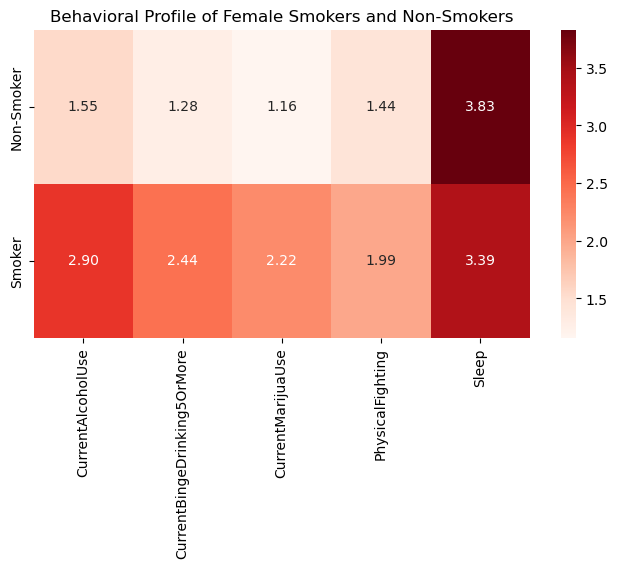

In [198]:
# 11. Behavioral Profile Heatmap

plt.figure(figsize=(8, 4))

sns.heatmap(
    profile_table,
    annot=True,
    cmap="Reds",
    fmt=".2f"
)

plt.title(
    "Behavioral Profile of Female Smokers and Non-Smokers"
)

plt.ylabel("")

plt.show()

### Interpretation

The heatmap shows that female smokers generally reported higher average levels of:

- alcohol use
- binge drinking
- marijuana use
- physical fighting

compared with female non-smokers.

Sleep showed the opposite direction. Female smokers had lower average sleep scores, suggesting shorter average sleep duration.

## 12. Mann–Whitney U Tests

Because the behavioral variables are ordinal rather than truly continuous, Mann–Whitney U tests are used instead of independent t-tests.

This non-parametric method is more appropriate for comparing ordinal behavioral variables between two groups.

In [199]:
# 12. Mann–Whitney U Tests

mannwhitney_results = []

for var in profile_vars:

    temp_df = female_profile_df[
        ["SmokingBinary", var]
    ].dropna()

    non_smoker = temp_df[
        temp_df["SmokingBinary"] == "Non-Smoker"
    ][var]

    smoker = temp_df[
        temp_df["SmokingBinary"] == "Smoker"
    ][var]

    stat, p = mannwhitneyu(
        non_smoker,
        smoker,
        alternative="two-sided"
    )

    mannwhitney_results.append({
        "Variable": var,
        "U statistic": round(stat, 2),
        "p-value": p
    })

mannwhitney_results_df = pd.DataFrame(
    mannwhitney_results
)

mannwhitney_results_df

,Variable,U statistic,p-value
0,CurrentAlcoholUse,1403637.0,7.507647e-269
1,CurrentBingeDrinking5OrMore,2124770.0,6.281928e-259
2,CurrentMarijuaUse,2278449.0,6.812433e-292
3,PhysicalFighting,2975824.0,7.037538e-70
4,Sleep,3728539.5,8.486352e-27


In [200]:
# Format p-values

mannwhitney_results_df[
    "p-value formatted"
] = mannwhitney_results_df[
    "p-value"
].apply(
    lambda x: "<0.001"
    if x < 0.001
    else round(x, 4)
)

mannwhitney_results_df

,Variable,U statistic,p-value,p-value formatted
0,CurrentAlcoholUse,1403637.0,7.507647e-269,<0.001
1,CurrentBingeDrinking5OrMore,2124770.0,6.281928e-259,<0.001
2,CurrentMarijuaUse,2278449.0,6.812433e-292,<0.001
3,PhysicalFighting,2975824.0,7.037538e-70,<0.001
4,Sleep,3728539.5,8.486352e-27,<0.001


### Statistical Interpretation

The Mann–Whitney U tests indicate whether the distributions of behavioral variables differ between female smokers and female non-smokers.

In this analysis, all p-values were below 0.001, suggesting statistically significant differences across all behavioral variables.

## 13. SadOrHopeless Analysis

`SadOrHopeless` is analyzed separately because it is a binary psychological variable rather than an ordinal behavioral variable.

The YRBS questionnaire asks whether students felt so sad or hopeless almost every day for two weeks or more in a row that they stopped doing some usual activities during the past 12 months.

The analysis compares the percentage of female smokers and female non-smokers who reported sadness or hopelessness.

In [201]:
# 13. SadOrHopeless Percentage Table

sad_table = pd.crosstab(
    female_profile_df["SmokingBinary"],
    female_profile_df["SadOrHopeless"],
    normalize="index"
) * 100

sad_table.round(2)

SadOrHopeless,1.0,2.0
SmokingBinary,,
Non-Smoker,32.82,67.18
Smoker,53.82,46.18


### Interpretation

In this table:

- code 1 represents Yes
- code 2 represents No

Therefore, the percentage under code 1 represents students who reported sadness or hopelessness.

Female smokers showed a substantially higher percentage of sadness or hopelessness compared with female non-smokers.

In [202]:
# 13. Chi-square Test

temp_df = female_profile_df[
    ["SmokingBinary", "SadOrHopeless"]
].dropna()

contingency_table = pd.crosstab(
    temp_df["SmokingBinary"],
    temp_df["SadOrHopeless"]
)

chi2, p, dof, expected = chi2_contingency(
    contingency_table
)

print(
    "Chi-square statistic:",
    round(chi2, 2)
)

if p < 0.001:
    print("p-value: <0.001")
else:
    print("p-value:", round(p, 4))

Chi-square statistic: 214.61
p-value: <0.001


### Psychological Interpretation

The chi-square test evaluates whether smoking behavior and sadness or hopelessness are statistically associated.

The significant p-value suggests that female smokers and female non-smokers differ significantly in reported sadness or hopelessness.

## 14. Grouped Bar Chart

A grouped bar chart is used to visually compare behavioral levels between female smokers and female non-smokers.

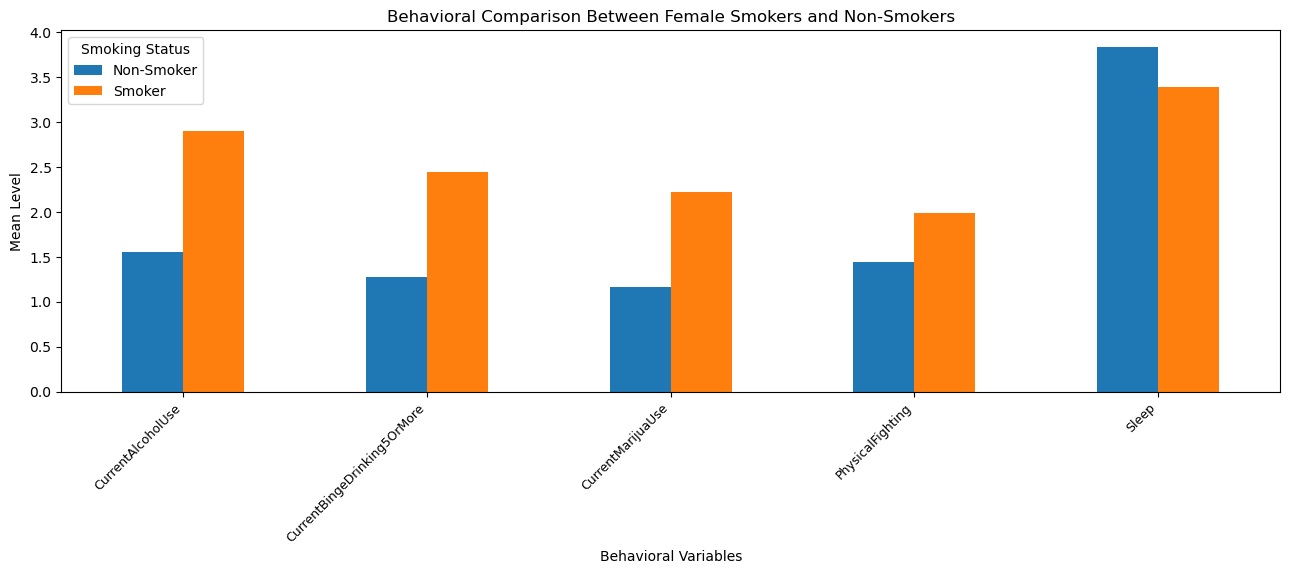

In [203]:
# 14. Grouped Bar Chart

profile_plot = profile_table.T

profile_plot.plot(
    kind="bar",
    figsize=(13, 6)
)

plt.title(
    "Behavioral Comparison Between Female Smokers and Non-Smokers"
)

plt.ylabel("Mean Level")

plt.xlabel("Behavioral Variables")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.legend(
    title="Smoking Status"
)

plt.tight_layout()

plt.xticks(fontsize=9)

plt.show()

# Interpretation

The grouped bar chart shows that female smokers reported higher average levels of alcohol use, binge drinking, marijuana use, and physical fighting than female non-smokers.

For sleep, female smokers showed lower average sleep scores, indicating shorter average sleep duration.

## 15. Summary of Findings

This extension analysis examined whether female smokers showed different behavioral and psychological characteristics compared with female non-smokers.

The results showed that female smokers reported higher average levels of:

- alcohol use
- binge drinking
- marijuana use
- physical fighting

Female smokers were also more likely to report sadness or hopelessness during the past 12 months.

For sleep, female smokers reported lower average sleep scores. Since the sleep variable is coded from shorter to longer sleep duration, this suggests that female smokers tended to report shorter sleep duration.

The Mann–Whitney U tests showed statistically significant differences across all ordinal behavioral variables. The chi-square test also showed a statistically significant association between smoking behavior and sadness or hopelessness.

## 16. Final Interpretation

Overall, the findings suggest that smoking behavior among female students may co-occur with multiple behavioral and psychological risk factors.

Female smoking was associated not only with cigarette use itself, but also with higher levels of:

- alcohol use
- binge drinking
- marijuana use
- physical fighting
- sadness or hopelessness

Female smokers also tended to report slightly shorter sleep duration.

These findings support the idea of a broader behavioral risk profile among female smokers.

However, this analysis is based on observational survey data. Therefore, the findings should be interpreted as associations rather than causal relationships.

In addition, this analysis did not account for survey design variables such as survey weights, strata, or PSU variables. Future analyses could extend this work by considering smoking intensity groups or applying survey-weighted methods.

This extension analysis provides additional insight beyond the original Cycle 3 research question by exploring behavioral patterns associated with smoking among female students.

# Notebook 2 Completion Checklist

Before moving to Notebook 3, confirm that the following components are completed:

- Female subset selection
- Sex coding verification
- Missing value check
- Variable coding check
- Sleep coding confirmation
- Binary smoking classification
- Behavioral mean comparison
- Difference analysis
- Heatmap visualization
- Mann–Whitney U tests
- SadOrHopeless analysis
- Grouped bar chart
- Final interpretation